# Bayesian Optimization History Plotting

This notebook visualizes the results from BO hyperparameter tuning runs.
It reads CSV history files saved by `bo_hst_nn.py` and creates summary plots.

In [1]:
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Load History Data

Specify the path to your saved history CSV file.

In [2]:
# Update this path to your specific history file
# Example: history_path = Path("output_log/bo_hst_nn_history_0410_123456.csv")
history_path = Path("output_log/bo_hst_nn_history_MMDD_HHMMSS.csv")

# Or list all available history files
output_dir = Path("output_log")
if output_dir.exists():
    history_files = sorted(output_dir.glob("bo_hst_nn_history_*.csv"))
    print(f"Found {len(history_files)} history file(s):")
    for i, file in enumerate(history_files, 1):
        print(f"  {i}. {file.name}")
    
    if history_files:
        # Use the most recent file by default
        history_path = history_files[-1]
        print(f"\nUsing most recent: {history_path.name}")

Found 4 history file(s):
  1. bo_hst_nn_history_0408_185536.csv
  2. bo_hst_nn_history_0408_194203.csv
  3. bo_hst_nn_history_0408_194251.csv
  4. bo_hst_nn_history_0408_201831.csv

Using most recent: bo_hst_nn_history_0408_201831.csv


In [3]:
# Load the history data
history_df = pd.read_csv(history_path)

# Process the data
history_df["eval_index"] = np.arange(1, len(history_df) + 1)

# Parse hidden_sizes from string representation back to list
history_df["hidden_sizes"] = history_df["hidden_sizes"].apply(eval)
history_df["hidden_label"] = history_df["hidden_sizes"].apply(
    lambda values: "-".join(str(value) for value in values)
)
history_df["num_layers"] = history_df["hidden_sizes"].apply(len)
history_df["log10_learning_rate"] = np.log10(history_df["learning_rate"])
history_df["running_best_val_mse"] = history_df["best_val_mse"].cummin()
history_df["improved"] = (
    history_df["best_val_mse"] == history_df["running_best_val_mse"]
)

print(f"Loaded {len(history_df)} evaluations")
print(f"Best validation MSE: {history_df['best_val_mse'].min():.6e}")
history_df.head()

Loaded 19 evaluations
Best validation MSE: 6.866674e-02


,phase,step,candidate_index,hidden_sizes,batch_size,learning_rate,best_val_mse,final_val_mse,best_val_objective,final_val_objective,final_train_mse,fit_time_s,best_objective_so_far,eval_index,hidden_label,num_layers,log10_learning_rate,running_best_val_mse,improved
0,init,1,39,"[128, 64, 32]",64,0.0003,0.157494,0.157570,-0.157494,-0.157570,0.081428,152.334735,NaN,1,128-64-32,3,-3.522879,0.157494,True
1,init,2,25,"[64, 64, 64]",128,0.0010,0.083351,0.083566,-0.083351,-0.083566,0.045880,116.123431,NaN,2,64-64-64,3,-3.000000,0.083351,True
2,init,3,26,"[64, 64, 64]",128,0.0030,0.085905,0.086378,-0.085905,-0.086378,0.052696,43.507921,NaN,3,64-64-64,3,-2.522879,0.083351,False
3,init,4,43,"[128, 64, 32]",128,0.0010,0.150014,0.150374,-0.150014,-0.150374,0.073170,78.536244,NaN,4,128-64-32,3,-3.000000,0.083351,False
4,bo,5,18,"[64, 64, 64]",32,0.0003,0.098356,0.098548,-0.098356,-0.098548,0.055151,164.578834,-0.083351,5,64-64-64,3,-3.522879,0.083351,False


## Plot 1: Validation MSE by Evaluation

Shows each evaluated configuration and the incumbent best over time.

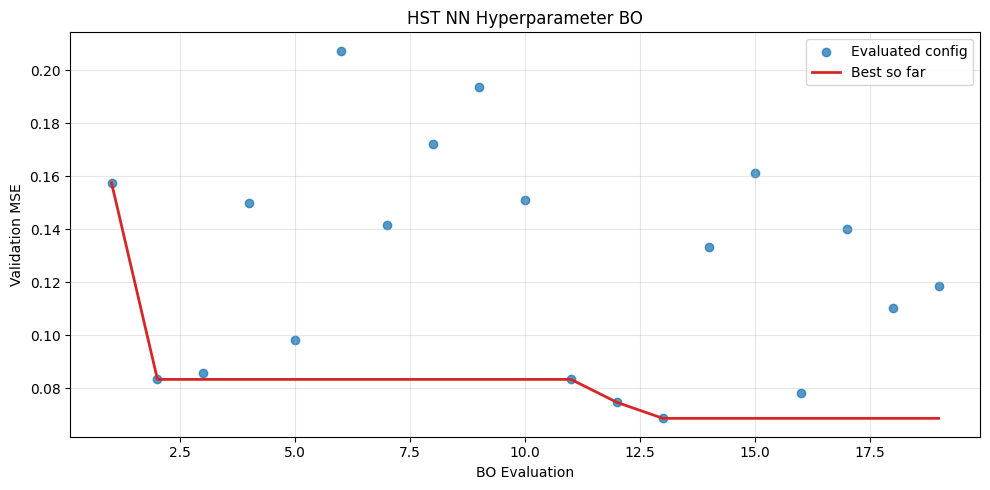

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(
    history_df["eval_index"],
    history_df["best_val_mse"],
    color="tab:blue",
    alpha=0.75,
    label="Evaluated config",
)
ax.plot(
    history_df["eval_index"],
    history_df["running_best_val_mse"],
    color="tab:red",
    linewidth=2,
    label="Best so far",
)
ax.set_xlabel("BO Evaluation")
ax.set_ylabel("Validation MSE")
ax.set_title("HST NN Hyperparameter BO")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()

# Optionally save
# plt.savefig("plots/bo_hst_nn_incumbent.png")
plt.show()

## Plot 2: Hyperparameter Trace

Shows how hyperparameters evolved during the BO process.

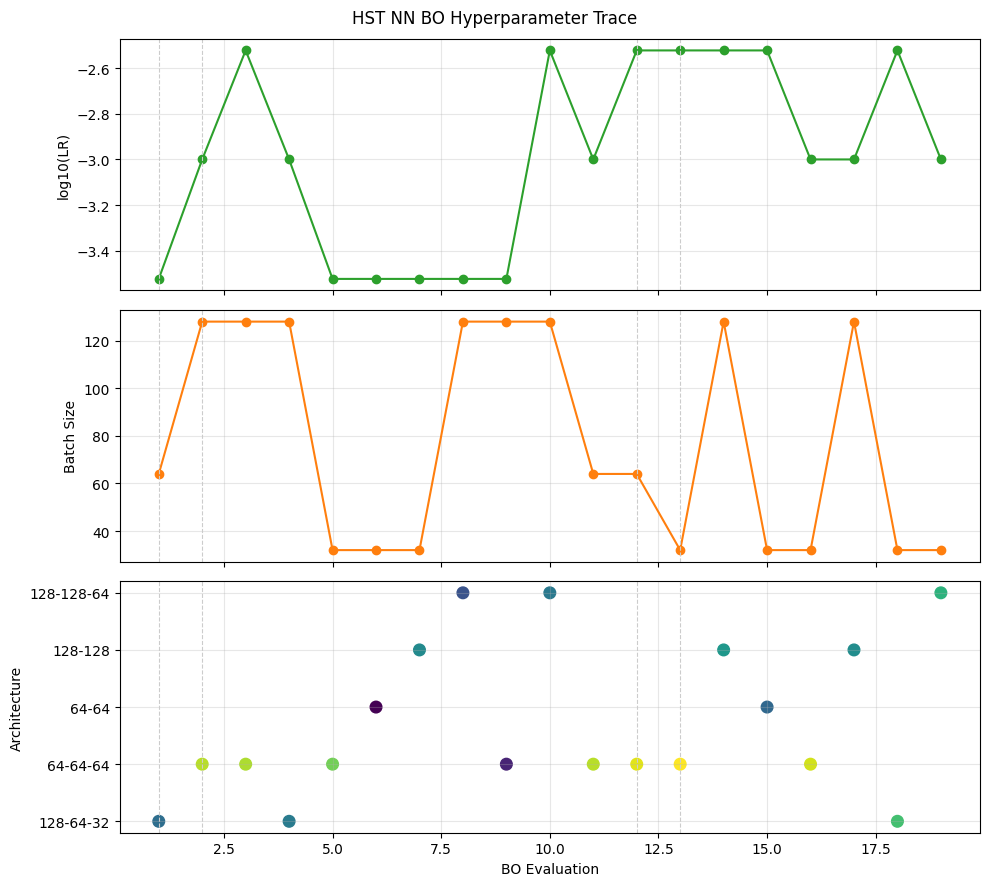

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axes[0].plot(
    history_df["eval_index"],
    history_df["log10_learning_rate"],
    marker="o",
    color="tab:green",
)
axes[0].set_ylabel("log10(LR)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    history_df["eval_index"],
    history_df["batch_size"],
    marker="o",
    color="tab:orange",
)
axes[1].set_ylabel("Batch Size")
axes[1].grid(True, alpha=0.3)

architecture_codes, architecture_labels = pd.factorize(history_df["hidden_label"])
axes[2].scatter(
    history_df["eval_index"],
    architecture_codes,
    c=history_df["best_val_mse"],
    cmap="viridis_r",
    s=70,
)
axes[2].set_yticks(np.arange(len(architecture_labels)))
axes[2].set_yticklabels(architecture_labels)
axes[2].set_ylabel("Architecture")
axes[2].set_xlabel("BO Evaluation")
axes[2].grid(True, alpha=0.3)

# Mark improvements with vertical lines
improvement_indices = history_df.loc[history_df["improved"], "eval_index"]
for ax in axes:
    for eval_index in improvement_indices:
        ax.axvline(eval_index, color="0.8", linestyle="--", linewidth=0.8)

fig.suptitle("HST NN BO Hyperparameter Trace", y=0.98)
plt.tight_layout()

# Optionally save
# plt.savefig("plots/bo_hst_nn_trace.png")
plt.show()

## Plot 3: Hyperparameter Scatter

Learning rate vs batch size, colored by validation MSE. Point size indicates number of hidden layers.

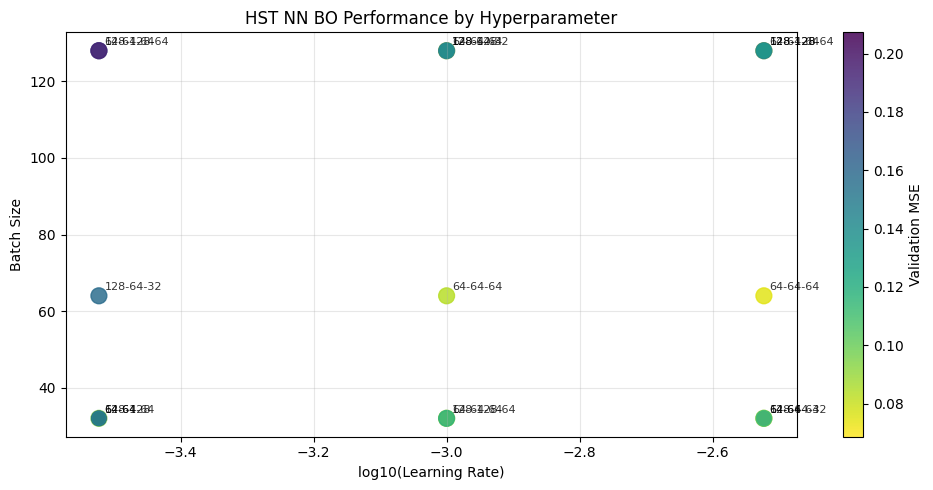

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(
    history_df["log10_learning_rate"],
    history_df["batch_size"],
    c=history_df["best_val_mse"],
    cmap="viridis_r",
    s=80 + 25 * (history_df["num_layers"] - 1),
    alpha=0.85,
)
for _, row in history_df.iterrows():
    ax.annotate(
        row["hidden_label"],
        (row["log10_learning_rate"], row["batch_size"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
        alpha=0.8,
    )
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Validation MSE")
ax.set_xlabel("log10(Learning Rate)")
ax.set_ylabel("Batch Size")
ax.set_title("HST NN BO Performance by Hyperparameter")
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Optionally save
# plt.savefig("plots/bo_hst_nn_scatter.png")
plt.show()

## Summary Statistics

In [7]:
print("Best configuration:")
best_idx = history_df["best_val_mse"].idxmin()
best_row = history_df.loc[best_idx]
print(f"  Hidden sizes: {best_row['hidden_sizes']}")
print(f"  Batch size: {best_row['batch_size']}")
print(f"  Learning rate: {best_row['learning_rate']:.2e}")
print(f"  Validation MSE: {best_row['best_val_mse']:.6e}")
print(f"  Found at evaluation: {best_row['eval_index']:.0f}")

print("\nImprovement timeline:")
improvements = history_df[history_df["improved"]]
for _, row in improvements.iterrows():
    print(f"  Eval {row['eval_index']:.0f}: MSE={row['best_val_mse']:.6e} ({row['hidden_label']}, bs={row['batch_size']:.0f}, lr={row['learning_rate']:.2e})")

Best configuration:
  Hidden sizes: [64, 64, 64]
  Batch size: 32
  Learning rate: 3.00e-03
  Validation MSE: 6.866674e-02
  Found at evaluation: 13

Improvement timeline:
  Eval 1: MSE=1.574942e-01 (128-64-32, bs=64, lr=3.00e-04)
  Eval 2: MSE=8.335105e-02 (64-64-64, bs=128, lr=1.00e-03)
  Eval 12: MSE=7.468423e-02 (64-64-64, bs=64, lr=3.00e-03)
  Eval 13: MSE=6.866674e-02 (64-64-64, bs=32, lr=3.00e-03)
